**1. Import Library**

In [ ]:
import os
import numpy as np
from glob import glob
from PIL import Image
import random
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

**2. Data Loader**

In [ ]:
def load_images_from_folder(folder, label, img_size=(128,128)):
    images = []
    labels = []

    for filename in glob(os.path.join(folder, "*")):
        try:
            img = Image.open(filename).convert("RGB")
            img = img.resize(img_size)
            img = np.array(img).astype(np.float32) / 255.0
            images.append(img)
            labels.append(label)
        except:
            pass

    return images, labels


def load_dataset(root, img_size=(128,128)):
    X, y = [], []
    class_names = sorted(os.listdir(root))

    for label, cls in enumerate(class_names):
        folder = os.path.join(root, cls)
        imgs, labs = load_images_from_folder(folder, label, img_size)
        X.extend(imgs)
        y.extend(labs)

    return np.array(X), np.array(y), class_names

**3. Load Train & Test**

In [ ]:
train_root = "/content/dataset/Train"
test_root  = "/content/dataset/Test"
IMG_SIZE = (128,128)

# Load train & test
X_train_full, y_train_full, class_names = load_dataset(train_root, IMG_SIZE)
X_test, y_test, _ = load_dataset(test_root, IMG_SIZE)

# Split train → 80% train, 20% val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=2025,
    stratify=y_train_full
)

print("Train:", X_train.shape)
print("Val:",   X_val.shape)
print("Test:",  X_test.shape)
print("Classes:", class_names)
num_classes = len(class_names)

Train: (4343, 128, 128, 3)
Val: (1086, 128, 128, 3)
Test: (300, 128, 128, 3)
Classes: ['Overripe', 'Ripe', 'Unripe']


**4. Visualize Dataset**

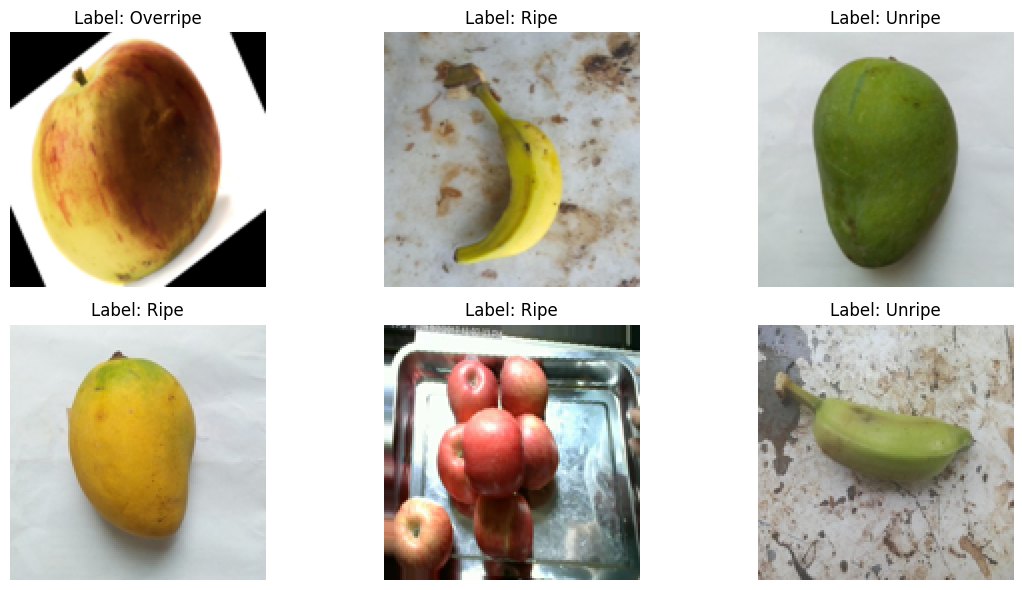

In [ ]:
plt.figure(figsize=(12,6))
for i in range(6):
    idx = random.randint(0, len(X_train)-1)
    plt.subplot(2,3,i+1)
    plt.imshow(X_train[idx])
    plt.title(f"Label: {class_names[y_train[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

**5. Model CNN**

In [ ]:
classes = sorted(os.listdir(train_root))
num_classes = len(classes)

cnn = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Dropout(0.3),
    layers.GlobalMaxPooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,147 (430.26 KB)

 Trainable params: 110,147 (430.26 KB)

 Non-trainable params: 0 (0.00 B)

**6. Callback**

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
checkpoint = ModelCheckpoint(filepath='super_cnn_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
callbacks_list = [early_stop, reduce_lr, checkpoint]

**7. Training**

In [ ]:
history = cnn.fit(
    X_train, y_train,
    epochs=35,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/35
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4735 - loss: 0.9498
Epoch 1: val_accuracy improved from -inf to 0.78545, saving model to super_cnn_model.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.4745 - loss: 0.9485 - val_accuracy: 0.7855 - val_loss: 0.5138 - learning_rate: 0.0010
Epoch 2/35
134/136 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7764 - loss: 0.5047
Epoch 2: val_accuracy improved from 0.78545 to 0.79834, saving model to super_cnn_model.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7763 - loss: 0.5051 - val_accuracy: 0.7983 - val_loss: 0.4932 - learning_rate: 0.0010
Epoch 3/35
133/136 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7831 - loss: 0.4850
Epoch 3: val_accuracy did not improve from 0.79834
136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7833 - loss: 0.4846 - val_accuracy: 0.7965 - val_loss: 0.4692 - learning_rate: 0.0010
Epoch 4/35
133/136 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8121 - lo

**8. Visualize Training**

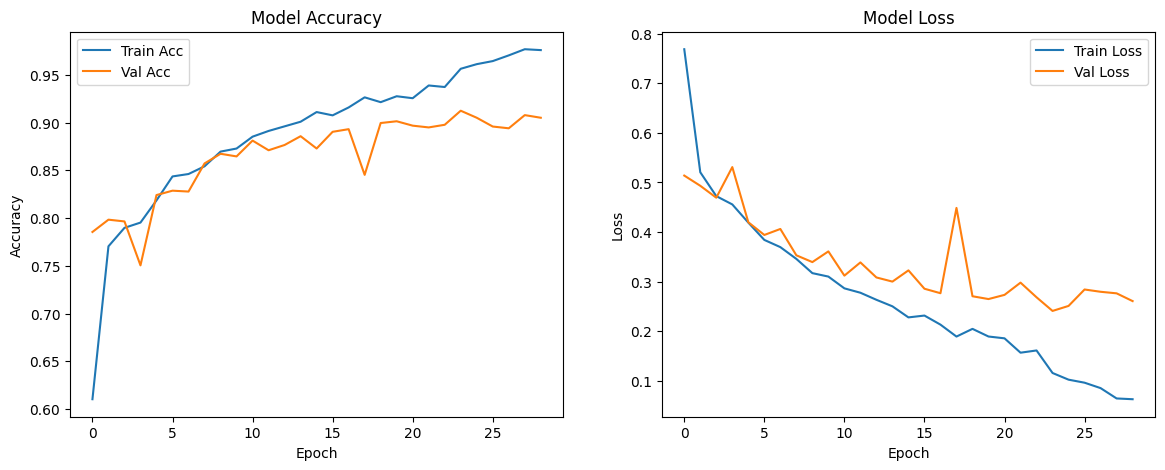

In [ ]:
plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

**9. Accuracy Model**

In [ ]:
best_model = tf.keras.models.load_model('super_cnn_model.keras')
test_loss, test_acc = best_model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.9113 - loss: 0.3175

Test Accuracy: 0.9167


**10. Classification Report & Confusion Matrix**

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
              precision    recall  f1-score   support

    Overripe     0.8598    0.9200    0.8889       100
        Ripe     0.9167    0.8800    0.8980       100
      Unripe     0.9794    0.9500    0.9645       100

    accuracy                         0.9167       300
   macro avg     0.9186    0.9167    0.9171       300
weighted avg     0.9186    0.9167    0.9171       300



<Figure size 800x600 with 0 Axes>

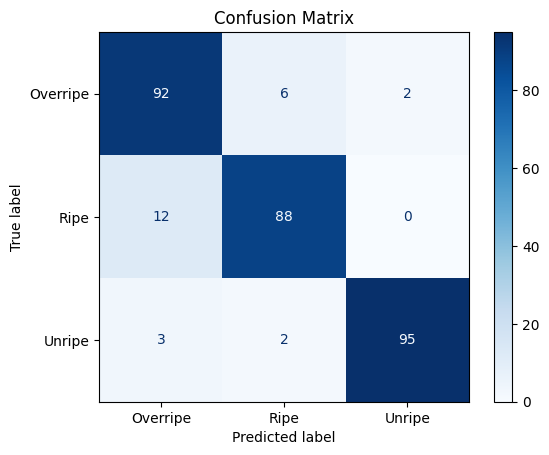

In [ ]:
y_pred = np.argmax(best_model.predict(X_test), axis=1)

# Classification Report
report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()

**11. Visualize Predict**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


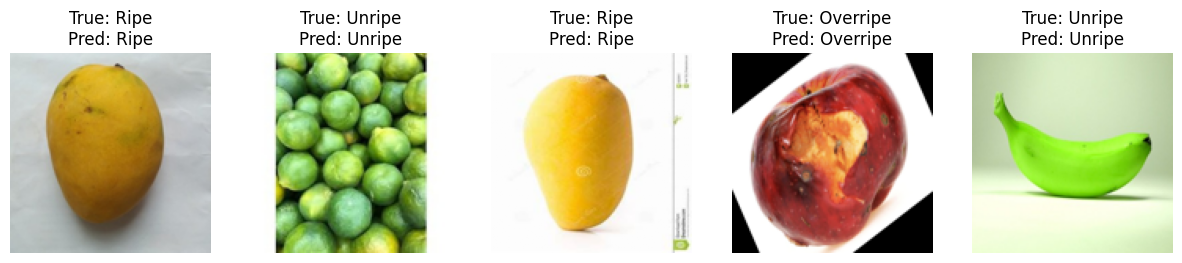

In [ ]:
plt.figure(figsize=(15, 5))
indices = random.sample(range(len(X_test)), 5)

for i, idx in enumerate(indices):
    img = X_test[idx]
    label = y_test[idx]
    prediction = np.argmax(best_model.predict(np.expand_dims(img, axis=0)))

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"True: {class_names[label]}\nPred: {class_names[prediction]}")
    plt.axis('off')

plt.show()

**12. Confidence**

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


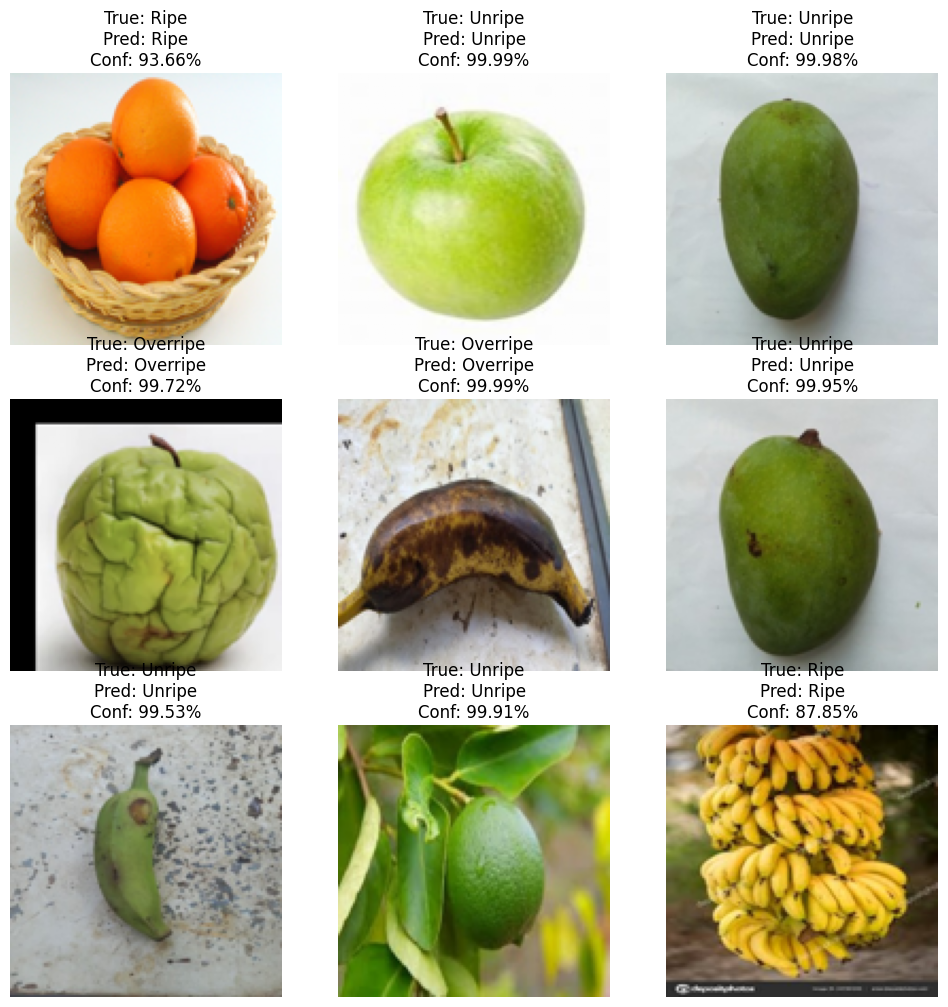

In [ ]:
y_pred = best_model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

idx = np.random.choice(len(X_test), 9, replace=False)
plt.figure(figsize=(12, 12))

for i, index in enumerate(idx):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[index])
    true_label = class_names[y_test[index]]
    pred_label = class_names[y_pred_labels[index]]
    confidence = np.max(y_pred[index]) * 100
    plt.title(f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}%')
    plt.axis('off')

plt.show()